# Patent Category Analysis

Counts how many patent figure records in the DeepPatent2 dataset relate to:
aircraft, drones/UAVs, helicopters, eVTOLs, spacecraft, ground vehicles, or marine craft.

**Data source:** per-year JSON files, each a list of records with `object`, `object_title`, and `caption` fields.

**Modules:**
- `categories.py` — keyword taxonomy
- `analyzer.py` — load / parse / match / aggregate

In [1]:
import sys
from pathlib import Path

# Absolute path to this notebook's folder — safe regardless of kernel CWD
NOTEBOOK_DIR = Path("/home/vasco/Vasco Workspace/Tese_Vasco_Lnx/Patent_Images_Extractor_&_FT_2.0/sidequests/DeepPatent2_DataSet_analyst")
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

# Input: DeepPatent2 per-year JSON files
DATA_DIR = Path("/home/vasco/Vasco Workspace/Tese_Vasco_Lnx/Drive_files_to_syncronize/DeepPatent2")

# Output: all saved files go here
OUTPUT_DIR = NOTEBOOK_DIR / "data"
OUTPUT_DIR.mkdir(exist_ok=True)

assert DATA_DIR.exists(), f"DATA_DIR not found: {DATA_DIR}"
print(f"Data directory  : {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"JSON files found: {len(list(DATA_DIR.glob('*.json')))}")

Data directory  : /home/vasco/Vasco Workspace/Tese_Vasco_Lnx/Drive_files_to_syncronize/DeepPatent2
Output directory: /home/vasco/Vasco Workspace/Tese_Vasco_Lnx/Patent_Images_Extractor_&_FT_2.0/sidequests/DeepPatent2_DataSet_analyst/data
JSON files found: 15


## Step 1 — Scan data directory

In [2]:
from analyzer import scan_data_dir

json_files = scan_data_dir(DATA_DIR)
print(f"JSON files found: {len(json_files)}")
for f in json_files:
    print(f"  {f.name}")

JSON files found: 15
  design2008.json
  design2009.json
  design2010.json
  design2011.json
  design2012.json
  design2013.json
  design2014.json
  design2015.json
  design2016.json
  design2017.json
  design2018.json
  design2019.json
  design2019part3.json
  design2020.json
  segmentation_2007.json


## Step 2 — Run parsing and categorisation

In [3]:
from analyzer import run_analysis

results = run_analysis(DATA_DIR)

print(f"Files processed : {results['files_found']}")
print(f"Total records   : {results['total_records']:,}")
print(f"Uncategorised   : {results['uncategorized']:,}")

if results['file_errors']:
    print(f"\nFiles with parse errors ({len(results['file_errors'])}):",
          ", ".join(results['file_errors']))

Files processed : 15
Total records   : 2,459,729
Uncategorised   : 2,261,963


## Step 3 — Results table

In [4]:
import pandas as pd
import json

counts = results["category_counts"]
total  = results["total_records"]

df = (
    pd.DataFrame(
        [{"Category": cat, "Matches": n, "% of Total": round(100 * n / total, 3)}
         for cat, n in sorted(counts.items(), key=lambda x: x[1], reverse=True)]
    )
    .reset_index(drop=True)
)

uncategorised_row = pd.DataFrame([{
    "Category": "(Uncategorised)",
    "Matches": results["uncategorized"],
    "% of Total": round(100 * results["uncategorized"] / total, 3)
}])
df = pd.concat([df, uncategorised_row], ignore_index=True)

# Save counts to JSON
counts_out = OUTPUT_DIR / "category_counts.json"
with open(counts_out, "w") as f:
    json.dump(
        {"total_records": total, "category_counts": counts, "uncategorized": results["uncategorized"]},
        f, indent=2
    )
print(f"Counts saved → {counts_out}")

# Save table to CSV
csv_out = OUTPUT_DIR / "category_counts.csv"
df.to_csv(csv_out, index=False)
print(f"Table  saved → {csv_out}")

display(df.style.format({"Matches": "{:,}", "% of Total": "{:.3f}%"}).hide(axis="index"))

Counts saved → /home/vasco/Vasco Workspace/Tese_Vasco_Lnx/Patent_Images_Extractor_&_FT_2.0/sidequests/DeepPatent2_DataSet_analyst/data/category_counts.json
Table  saved → /home/vasco/Vasco Workspace/Tese_Vasco_Lnx/Patent_Images_Extractor_&_FT_2.0/sidequests/DeepPatent2_DataSet_analyst/data/category_counts.csv


Category,Matches,% of Total
Ground Vehicle,"146,972",5.975%
Spacecraft / Rocket,"21,563",0.877%
Marine / Watercraft,"17,452",0.710%
Aircraft (Fixed-Wing),"13,968",0.568%
Drone / UAV,"3,061",0.124%
Helicopter / Rotorcraft,"2,266",0.092%
eVTOL / Advanced Air Mobility,"1,146",0.047%
(Uncategorised),"2,261,963",91.960%


## Step 4 — Visualisation

/tmp/ipykernel_57139/649822110.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(
/tmp/ipykernel_57139/649822110.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")


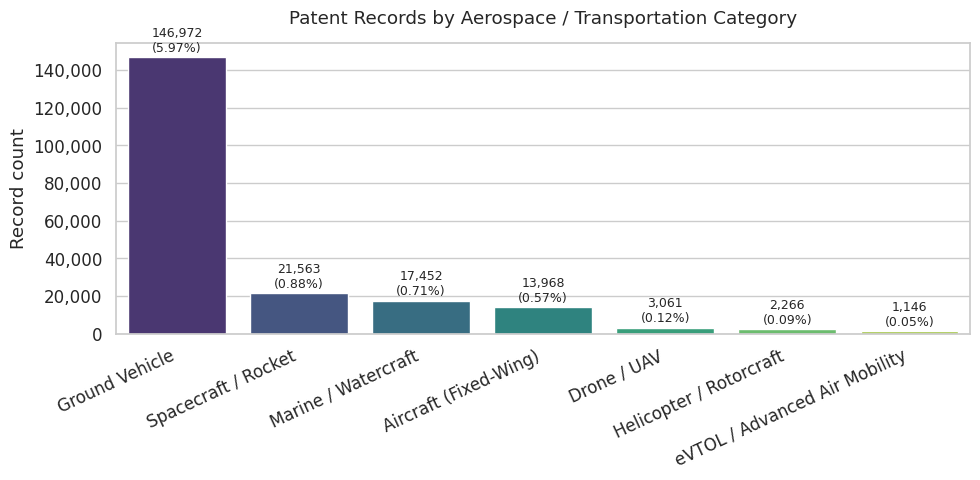

Chart  saved → /home/vasco/Vasco Workspace/Tese_Vasco_Lnx/Patent_Images_Extractor_&_FT_2.0/sidequests/DeepPatent2_DataSet_analyst/data/category_distribution.png


In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plot_df = df[df["Category"] != "(Uncategorised)"].copy()

sns.set_theme(style="whitegrid", font_scale=1.1)
fig, ax = plt.subplots(figsize=(10, 5))

bars = sns.barplot(
    data=plot_df,
    x="Category",
    y="Matches",
    palette="viridis",
    ax=ax,
)

for bar, (_, row) in zip(bars.patches, plot_df.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(plot_df["Matches"]) * 0.01,
        f"{int(row['Matches']):,}\n({row['% of Total']:.2f}%)",
        ha="center", va="bottom", fontsize=9,
    )

ax.set_title("Patent Records by Aerospace / Transportation Category", pad=14)
ax.set_xlabel("")
ax.set_ylabel("Record count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")

plt.tight_layout()
chart_out = OUTPUT_DIR / "category_distribution.png"
plt.savefig(chart_out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart  saved → {chart_out}")

## Step 5 — Inspect sample records (optional)

Preview matching records for any category to spot false positives or tune keywords.

In [6]:
INSPECT_CATEGORY = "Aircraft (Fixed-Wing)"   # ← change as needed
N_SAMPLES = 10

sample_records = results["category_records"].get(INSPECT_CATEGORY, [])[:N_SAMPLES]

if not sample_records:
    print(f"No records found for '{INSPECT_CATEGORY}'.")
else:
    sample_df = pd.DataFrame(sample_records)[
        [c for c in ("patentID", "object", "object_title", "caption") if c in sample_records[0]]
    ]
    pd.set_option("display.max_colwidth", 120)
    display(sample_df)

,patentID,object,object_title,caption
0,USD0574572-20080805,elevator brake,Elevator brake,FIG. 5 is a left side elevation view thereof;
1,USD0560591-20080129,spot welded stainless steel aircraft firewall fire conduit,Spot welded stainless steel aircraft firewall fire conduit,FIG. 5 is a bottom plan view thereof.
2,USD0579400-20081028,propeller guard,Propeller guard,FIG. 4 is a reduced right side elevation view thereof;
3,USD0576538-20080909,propeller,Propeller,"FIG. 4 is a side view thereof; and,"
4,USD0567176-20080422,floating wind turbine tower,Floating wind turbine tower,FIG. 1 is a side view of a floating wind turbine tower showing our new design;
5,USD0565175-20080325,water jet base,Water jet base,FIG. 4 is a rear elevation thereof;
6,USD0571913-20080624,endoscopic facelift elevator,Endoscopic facelift elevator,FIG. 1 is a right side elevational view of an endoscopic facelift elevator showing my new design;
7,USD0575245-20080819,light emitting diode assembly for plane illumination,Matrix type light emitting diode assembly,FIG. 5 is a right side elevation view thereof;
8,USD0560425-20080129,sleeve container with tray,Sleeve container with tray for the transport and handling of goods,FIG. 10 is a bottom plan view of the second embodiment thereof;
9,USD0561679-20080212,helicopter propeller,Helicopter propeller,FIG. 5 is a top view thereof.
